In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Bin Configuration
BIN_HEIGHT = 100  # cm

# Simulate 50 readings
records = []

current_time = datetime.now()

for i in range(50):

    # Simulate waste increasing
    distance = np.random.randint(5, 100)

    fill_percentage = round(
        ((BIN_HEIGHT - distance) / BIN_HEIGHT) * 100, 2
    )

    if fill_percentage < 40:
        status = "Empty"
    elif fill_percentage < 80:
        status = "Half Full"
    else:
        status = "Full"

    alert = "YES" if fill_percentage >= 80 else "NO"

    records.append([
        current_time + timedelta(minutes=i),
        distance,
        fill_percentage,
        status,
        alert
    ])

df = pd.DataFrame(
    records,
    columns=[
        "Timestamp",
        "Distance(cm)",
        "Fill Percentage",
        "Bin Status",
        "Alert"
    ]
)

df.head()

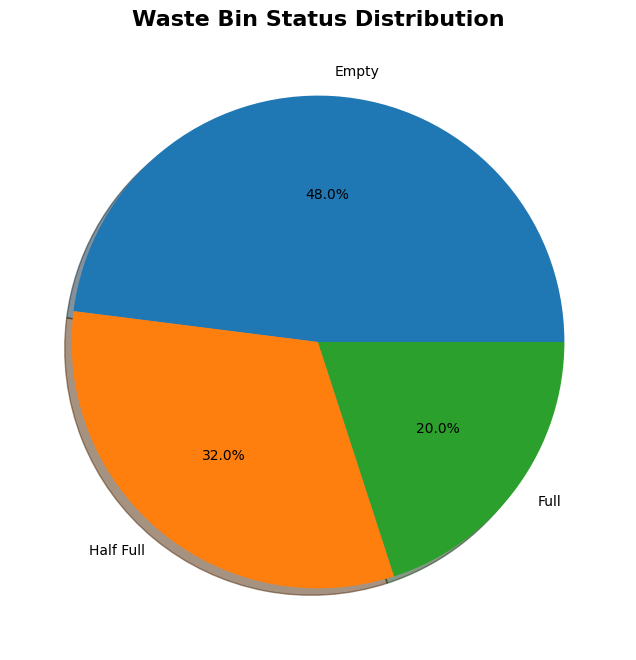

In [4]:
status_counts = df["Bin Status"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    shadow=True
)

plt.title(
    "Waste Bin Status Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.show()

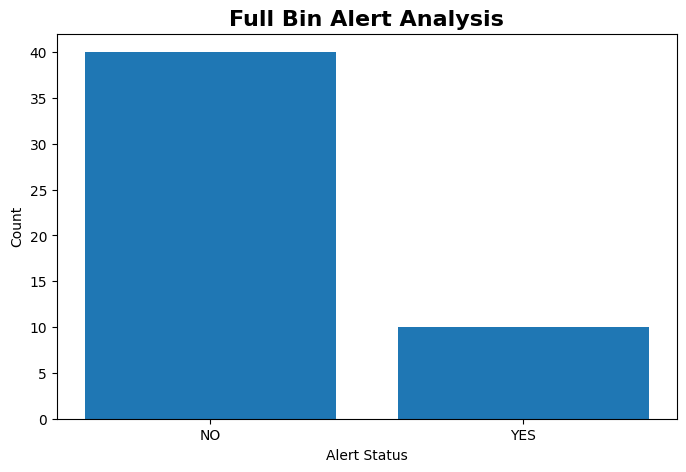

In [5]:
alerts = df["Alert"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    alerts.index,
    alerts.values
)

plt.title(
    "Full Bin Alert Analysis",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Alert Status")
plt.ylabel("Count")

plt.show()

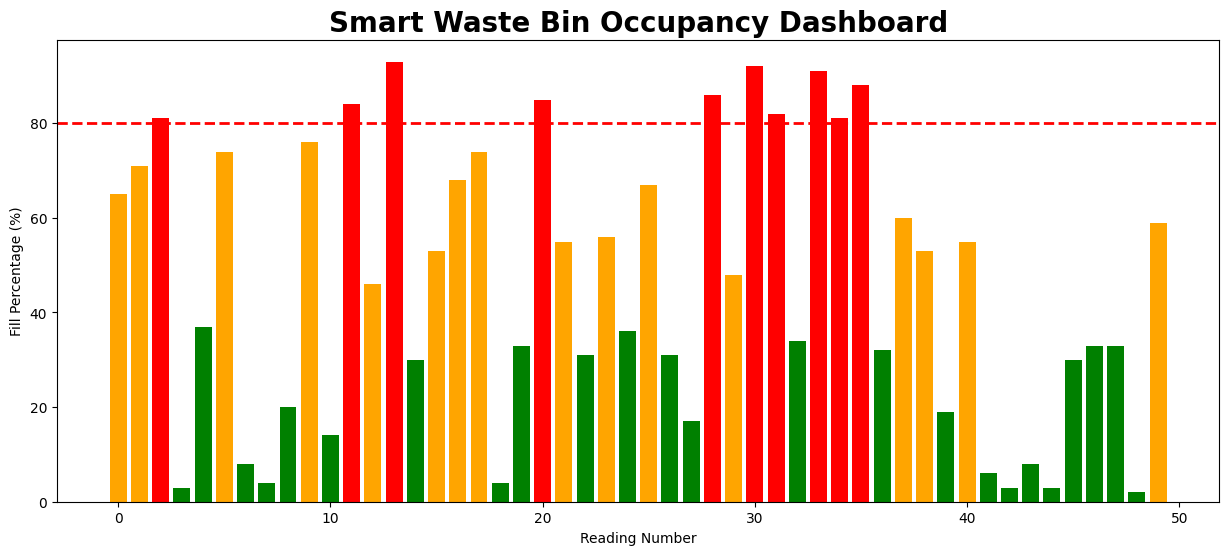

In [6]:
fig, ax = plt.subplots(figsize=(15,6))

colors = []

for value in df["Fill Percentage"]:
    if value < 40:
        colors.append("green")
    elif value < 80:
        colors.append("orange")
    else:
        colors.append("red")

ax.bar(
    range(len(df)),
    df["Fill Percentage"],
    color=colors
)

ax.axhline(
    y=80,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.title(
    "Smart Waste Bin Occupancy Dashboard",
    fontsize=20,
    fontweight='bold'
)

plt.xlabel("Reading Number")
plt.ylabel("Fill Percentage (%)")

plt.show()

In [7]:
!pip install reportlab

from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

pdf = SimpleDocTemplate("Waste_Bin_Report.pdf")

styles = getSampleStyleSheet()

content = []

content.append(
    Paragraph(
        "Smart Waste Management & Bin Level Detection System",
        styles['Title']
    )
)

content.append(Spacer(1,12))

content.append(
    Paragraph(
        f"Total Readings: {len(df)}",
        styles['Normal']
    )
)

content.append(
    Paragraph(
        f"Full Bin Alerts: {(df['Alert']=='YES').sum()}",
        styles['Normal']
    )
)

pdf.build(content)

print("PDF Generated")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.9 MB/s eta 0:00:00
PDF Generated
